In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score,precision_score,precision_recall_curve, recall_score, f1_score, average_precision_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [3]:
df = pd.read_csv("online_shoppers_intention_preprocessed.csv")  
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,1,1,1,1,1,0,0
1,0,0.0,0,0.0,2,64.00,0.00,0.10,0.0,0.0,2,2,2,1,2,1,0,0
2,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,4,1,9,3,1,0,0
3,0,0.0,0,0.0,2,2.67,0.05,0.14,0.0,0.0,2,3,2,2,4,1,0,0
4,0,0.0,0,0.0,10,627.50,0.02,0.05,0.0,0.0,2,3,3,1,4,1,1,0


In [4]:
df.keys

<bound method NDFrame.keys of        Administrative  Administrative_Duration  Informational  \
0                   0                      0.0              0   
1                   0                      0.0              0   
2                   0                      0.0              0   
3                   0                      0.0              0   
4                   0                      0.0              0   
...               ...                      ...            ...   
12200               3                    145.0              0   
12201               0                      0.0              0   
12202               0                      0.0              0   
12203               4                     75.0              0   
12204               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                         0.0               1                     0.00   
1                         0.0            

In [5]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_rnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_rnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print(X_train_rnn.shape)

(9764, 17, 1)


In [9]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(64, return_sequences=True,
                        input_shape=(X_train_rnn.shape[1], 1)))

rnn_model.add(Dropout(0.3))

rnn_model.add(SimpleRNN(32))

rnn_model.add(Dropout(0.3))

rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

C:\Users\Garkjf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 17, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = rnn_model.fit(
    X_train_rnn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8607 - loss: 0.3459 - val_accuracy: 0.8894 - val_loss: 0.2802
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8802 - loss: 0.3104 - val_accuracy: 0.8781 - val_loss: 0.3157
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8844 - loss: 0.2989 - val_accuracy: 0.8904 - val_loss: 0.2721
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8845 - loss: 0.2961 - val_accuracy: 0.8858 - val_loss: 0.2921
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8852 - loss: 0.2867 - val_accuracy: 0.8945 - val_loss: 0.2672
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8886 - loss: 0.2824 - val_accuracy: 0.8920 - val_loss: 0.2698
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8904 - loss: 0.2786 - val_accuracy: 0.8945 - val_loss: 0.2618
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8935 - loss: 0.2726 - val_accuracy: 0.

In [11]:
y_prob_rnn = rnn_model.predict(X_test_rnn)

y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [12]:
print("RNN Accuracy:", accuracy_score(y_test, y_pred_rnn))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rnn))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rnn))

RNN Accuracy: 0.8869315854158132

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      2079
           1       0.65      0.52      0.58       362

    accuracy                           0.89      2441
   macro avg       0.78      0.74      0.76      2441
weighted avg       0.88      0.89      0.88      2441


Confusion Matrix:

[[1976  103]
 [ 173  189]]


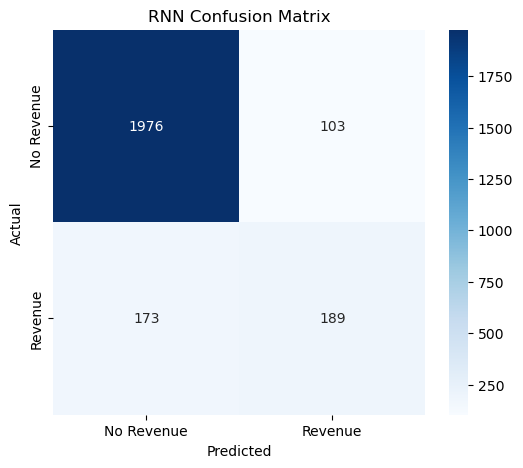

In [13]:
cm = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Revenue','Revenue'],
            yticklabels=['No Revenue','Revenue'])

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rnn)
auc = roc_auc_score(y_test, y_prob_rnn)

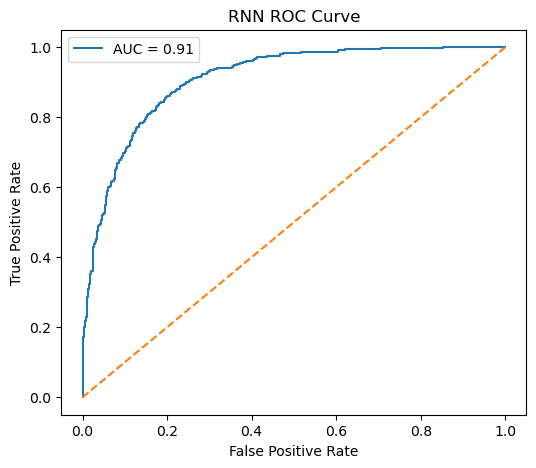

In [15]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("RNN ROC Curve")
plt.legend()

plt.show()

In [16]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_rnn)
ap_score = average_precision_score(y_test, y_prob_rnn)

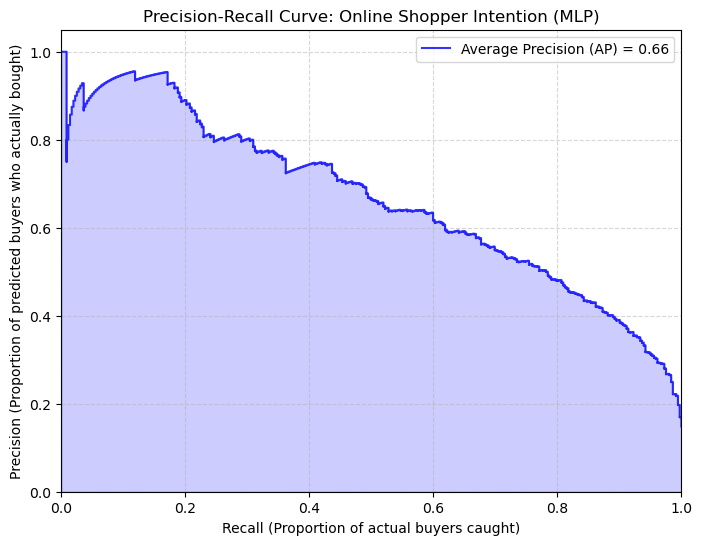

Average Precision (AP): 0.6643


In [17]:
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.8, where='post', label=f'Average Precision (AP) = {ap_score:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Proportion of actual buyers caught)')
plt.ylabel('Precision (Proportion of predicted buyers who actually bought)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve: Online Shopper Intention (MLP)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Average Precision (AP): {ap_score:.4f}")